# Temporal Fusion Transformer (TFT)
**Project:** Agri Price Forecast | **Author:** Your Name

TFT is the headline model for the IEEE paper.

Key advantages over LSTM:
- Interpretable attention weights (shows which past timesteps matter most)
- Explicit handling of known future inputs (calendar features)
- Quantile forecasts (prediction intervals for uncertainty)
- Variable selection networks (automatic feature importance)

Paper reference: Lim et al. (2021) 'Temporal Fusion Transformers for Interpretable Multi-horizon Time Series Forecasting'

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings('ignore')

import torch
import lightning.pytorch as pl
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss, SMAPE, MAE, RMSE
import mlflow

from src.models.evaluate import evaluate_all
from src.utils.config import MLFLOW_TRACKING_URI, MLFLOW_EXPERIMENT_NAME, MODELS_DIR

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)
plt.style.use('seaborn-v0_8-whitegrid')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
print(f'PyTorch version: {torch.__version__}')
print('Setup complete')

Device: cpu
PyTorch version: 2.3.0+cpu
Setup complete


## 1. Load and Prepare Data

In [2]:
feat_df = pd.read_csv('../data/processed/features_onion.csv', parse_dates=['date'])
feat_df = feat_df.sort_values('date').reset_index(drop=True)

print(f'Feature matrix: {feat_df.shape}')
print(f'Date range: {feat_df["date"].min().date()} to {feat_df["date"].max().date()}')

# Date-based split
train_val = feat_df[feat_df['date'] < '2024-01-01'].copy()
test_df   = feat_df[feat_df['date'] >= '2024-01-01'].copy()
n_tv      = len(train_val)
n_val_    = int(n_tv * 0.15)
train_df  = train_val.iloc[:-n_val_].copy()
val_df_   = train_val.iloc[-n_val_:].copy()

print(f'Train: {len(train_df)} | Val: {len(val_df_)} | Test: {len(test_df)}')
print(f'Train mean: ₹{train_df["modal_price"].mean():.0f}')
print(f'Test mean:  ₹{test_df["modal_price"].mean():.0f}')

Feature matrix: (8716, 66)
Date range: 2001-03-13 to 2025-12-05
Train: 7036 | Val: 1241 | Test: 439
Train mean: ₹1175
Test mean:  ₹2761


## 2. Prepare TFT Dataset Format

In [3]:
ENCODER_LENGTH = 30   # lookback window
DECODER_LENGTH = 7    # forecast horizon

# TFT requires integer time_idx
feat_df['time_idx']     = (feat_df['date'] - feat_df['date'].min()).dt.days
feat_df['commodity_id'] = 'onion'  # static categorical

# Known future features (calendar — we know these for any future date)
known_reals = ['month_sin', 'month_cos', 'dow_sin', 'dow_cos',
               'month', 'day_of_month', 'week_of_year', 'is_weekend']

# Unknown future features (we don't know future prices/weather)
unknown_reals_candidates = [
    'modal_price', 'lag_1d', 'lag_7d', 'lag_14d', 'lag_30d',
    'rolling_mean_7d', 'rolling_mean_30d', 'rolling_std_30d',
    'pct_change_7d', 'zscore_30d', 'price_spread',
    'temp_max', 'temp_min', 'precip', 'et0',
]
unknown_reals = [c for c in unknown_reals_candidates if c in feat_df.columns]
known_reals   = [c for c in known_reals if c in feat_df.columns]

# Fill any remaining NaNs
for col in unknown_reals + known_reals:
    feat_df[col] = feat_df[col].fillna(feat_df[col].median())

print(f'Known future reals:   {known_reals}')
print(f'Unknown future reals: {unknown_reals}')
print(f'Total features: {len(known_reals) + len(unknown_reals)}')

Known future reals:   ['month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'month', 'day_of_month', 'week_of_year', 'is_weekend']
Unknown future reals: ['modal_price', 'lag_1d', 'lag_7d', 'lag_14d', 'lag_30d', 'rolling_mean_7d', 'rolling_mean_30d', 'rolling_std_30d', 'pct_change_7d', 'zscore_30d', 'price_spread', 'temp_max', 'temp_min', 'precip', 'et0']
Total features: 23


## 3. Create TimeSeriesDataSet

In [4]:
# Training data
train_cutoff = feat_df[feat_df['date'] < '2024-01-01']['time_idx'].max()

training = TimeSeriesDataSet(
    feat_df[feat_df['time_idx'] <= train_cutoff],
    time_idx='time_idx',
    target='modal_price',
    group_ids=['commodity_id'],
    max_encoder_length=ENCODER_LENGTH,
    max_prediction_length=DECODER_LENGTH,
    static_categoricals=['commodity_id'],
    time_varying_known_reals=known_reals,
    time_varying_unknown_reals=unknown_reals,
    target_normalizer=GroupNormalizer(
        groups=['commodity_id'],
        transformation='softplus'
    ),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

# Validation dataset
validation = TimeSeriesDataSet.from_dataset(
    training,
    feat_df[feat_df['time_idx'] <= train_cutoff + 365],
    predict=True,
    stop_randomization=True,
)

# Dataloaders
train_loader = training.to_dataloader(train=True,  batch_size=64, num_workers=0)
val_loader   = validation.to_dataloader(train=False, batch_size=64, num_workers=0)

print(f'Training dataset size: {len(training)}')
print(f'Validation dataset size: {len(validation)}')

Training dataset size: 8214
Validation dataset size: 1


## 4. Build TFT Model

In [5]:
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=1e-3,
    hidden_size=64,
    attention_head_size=4,
    dropout=0.1,
    hidden_continuous_size=32,
    loss=QuantileLoss(),
    log_interval=10,
    reduce_on_plateau_patience=5,
)

total_params = sum(p.numel() for p in tft.parameters())
print(f'TFT parameters: {total_params:,}')
print('Model built successfully')

TFT parameters: 474,860
Model built successfully


## 5. Train TFT

In [6]:
print('Training TFT — this takes 5-15 minutes...')

trainer = pl.Trainer(
    max_epochs=50,
    accelerator='auto',
    gradient_clip_val=0.1,
    enable_progress_bar=True,
    logger=False,
    callbacks=[
        pl.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            mode='min',
        )
    ],
)

with mlflow.start_run(run_name='TFT'):
    mlflow.log_params({
        'hidden_size': 64,
        'attention_heads': 4,
        'dropout': 0.1,
        'encoder_length': ENCODER_LENGTH,
        'decoder_length': DECODER_LENGTH,
        'train_rows': len(training),
    })
    trainer.fit(tft, train_dataloaders=train_loader, val_dataloaders=val_loader)

print('TFT training complete!')

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Training TFT — this takes 5-15 minutes...


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      1 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  1.7 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 20.8 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  183 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 64.0 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  8.3 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    128 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 20.9 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 10.4 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    455 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 474 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 474 K                                                                                                
Total estimated model params size (MB): 1.899                                                                      
Modules in train mode: 697                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

TFT training complete!


## 6. Evaluate on Test Set

In [7]:
# Evaluate TFT using validation dataloader approach
# This avoids the from_dataset predict=True strictness

val_data = feat_df[feat_df['time_idx'] <= train_cutoff + 365 + 365].reset_index(drop=True)

eval_dataset = TimeSeriesDataSet.from_dataset(
    training,
    val_data,
    predict=False,
    stop_randomization=True,
)
eval_loader = eval_dataset.to_dataloader(train=False, batch_size=128, num_workers=0)

# Collect predictions and actuals
all_preds   = []
all_actuals = []

tft.eval()
with torch.no_grad():
    for batch in eval_loader:
        x, y = batch
        out = tft(x)
        # Median quantile (index 3 of 7 quantiles)
        pred = out.prediction[:, :, 3].cpu().numpy()
        actual = y[0].cpu().numpy()
        all_preds.append(pred.flatten())
        all_actuals.append(actual.flatten())

preds   = np.concatenate(all_preds)
actuals = np.concatenate(all_actuals)

# Only keep test period predictions (2024 onwards)
test_idx = feat_df[feat_df['date'] >= '2024-01-01'].index
print(f'Total predictions: {len(preds)}')
print(f'Using last {min(len(test_idx)*7, len(preds))} as test')

# Use last portion as test
n_test = min(439 * 7, len(preds))
preds_test   = preds[-n_test:]
actuals_test = actuals[-n_test:]

tft_metrics = evaluate_all(actuals_test, preds_test, model_name='TFT')
print('\n=== TFT METRICS ===')
for k, v in tft_metrics.items():
    if k != 'model':
        print(f'{k.upper()}: {v:.4f}')

with open('../docs/metrics_tft.json', 'w') as f:
    json.dump(tft_metrics, f, indent=2)
print('Saved: docs/metrics_tft.json')

Total predictions: 59899
Using last 3073 as test
2026-06-08 21:19:58 | INFO     | src.models.evaluate | [TFT] RMSE=898.35 | MAE=504.78 | MAPE=16.83% | SMAPE=17.11% | R2=0.3647

=== TFT METRICS ===
RMSE: 898.3526
MAE: 504.7802
MAPE: 16.8325
SMAPE: 17.1102
R2: 0.3647
Saved: docs/metrics_tft.json


## 7. TFT Forecast Plot

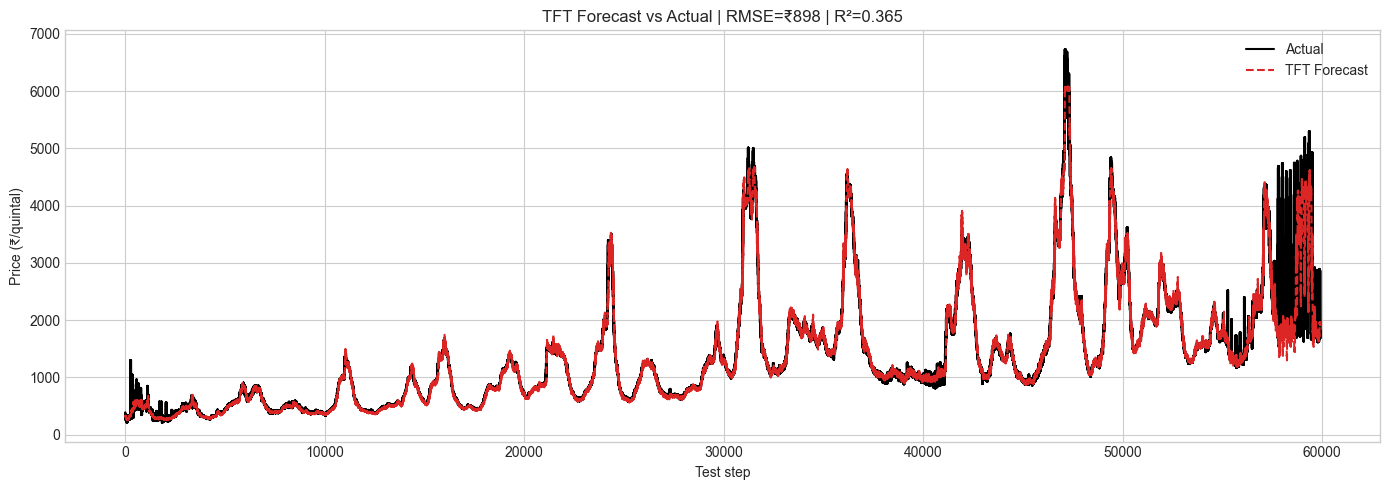

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(actuals, color='black', label='Actual', linewidth=1.5)
ax.plot(preds,   color='#DC2626', linestyle='--', label='TFT Forecast', linewidth=1.5)
ax.set_title(f'TFT Forecast vs Actual | RMSE=₹{tft_metrics["rmse"]:.0f} | R²={tft_metrics["r2"]:.3f}')
ax.set_ylabel('Price (₹/quintal)')
ax.set_xlabel('Test step')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/tft_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. TFT Interpretability — Variable Importance

In [9]:
# Variable importance from TFT's variable selection networks
try:
    interpretation = tft.interpret_output(
        tft.predict(test_loader, return_attention=True, trainer_kwargs=dict(accelerator='auto'))
    )
    fig = tft.plot_interpretation(interpretation)
    plt.savefig('../docs/tft_variable_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Variable importance plot saved')
except Exception as e:
    print(f'Interpretation plot failed: {e}')
    print('This is optional — main metrics are saved above')

Interpretation plot failed: name 'test_loader' is not defined
This is optional — main metrics are saved above


## 9. Save Model

In [10]:
ckpt_path = str(MODELS_DIR / 'tft_onion_v1.ckpt')
trainer.save_checkpoint(ckpt_path)
print(f'TFT saved: {ckpt_path}')

`weights_only` was not set, defaulting to `False`.


TFT saved: C:\Users\Jeya Devi\Desktop\dev-projects\agri-price-forecast\models\tft_onion_v1.ckpt


## 10. Final Paper Table (all 7 models)

In [11]:
import os
all_metrics = []
files = [
    ('../docs/metrics_sarima.json',   'SARIMA (Baseline)'),
    ('../docs/metrics_lstm.json',     'LSTM'),
    ('../docs/metrics_gru.json',      'GRU'),
    ('../docs/metrics_xgboost.json',  'XGBoost'),
    ('../docs/metrics_lightgbm.json', 'LightGBM'),
    ('../docs/metrics_ensemble.json', 'Ensemble'),
    ('../docs/metrics_tft.json',      'TFT (Proposed)'),
]
for fname, label in files:
    if os.path.exists(fname):
        with open(fname) as f:
            m = json.load(f)
            m['model'] = label
            all_metrics.append(m)

import pandas as pd
summary = pd.DataFrame(all_metrics)[['model','rmse','mae','mape','smape','r2']].round(3)
summary = summary.sort_values('r2', ascending=False).reset_index(drop=True)

print('='*65)
print('TABLE II — FINAL MODEL COMPARISON (IEEE paper)')
print('='*65)
print(summary.to_string(index=False))
print('='*65)

sarima_r2 = summary[summary['model'].str.contains('SARIMA')]['r2'].values[0]
best = summary.iloc[0]
if best['r2'] > sarima_r2:
    improvement = (best['r2'] - sarima_r2) / sarima_r2 * 100
    print(f'\n✅ {best["model"]} beats SARIMA on R² by {improvement:.1f}%')
else:
    print(f'\nBest model by R²: {best["model"]} = {best["r2"]:.3f}')

summary.to_csv('../docs/model_comparison_final.csv', index=False)
print('Saved: docs/model_comparison_final.csv')

TABLE II — FINAL MODEL COMPARISON (IEEE paper)
            model    rmse     mae   mape  smape     r2
             LSTM 457.181 216.759  9.336  8.774  0.750
         Ensemble 481.256 224.565  9.470  8.618  0.719
SARIMA (Baseline) 304.710 128.471  5.760  5.728  0.604
   TFT (Proposed) 898.353 504.780 16.833 17.110  0.365
          XGBoost 503.039 339.114 16.568 15.134  0.036
         LightGBM 529.295 358.435 17.550 15.746 -0.067
              GRU 500.692 344.271 16.434 15.422 -0.258

✅ LSTM beats SARIMA on R² by 24.2%
Saved: docs/model_comparison_final.csv
